# Instalacao de dependencias

In [1]:
import os, subprocess, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/rduarte12/information-retrieval-1.git"
REPO_DIR = "information-retrieval-1"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(os.path.join(REPO_DIR, "src"))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "../requirements.txt"], check=True)
    print(f"[Colab] repositorio clonado e dependencias instaladas. cwd = {os.getcwd()}")
else:
    print(f"[Local] cwd = {os.getcwd()} (esperado: .../information-retrieval-1/src)")

[Local] cwd = c:\Users\duart\directory\information-retrieval-1\src (esperado: .../information-retrieval-1/src)


In [2]:
import sys, os
sys.path.insert(0, os.getcwd())

from data_loader import load_cranfield

In [3]:
# fazer load de modos de tokenização, stopwords, stemmers do nltk

# punkt e punkt_tab: servem para tokenização de sentenças e palavras
# stopwords: lista de stopwords
# stemmer: algoritmo de stemming

import nltk

for resource in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.download(resource)
    except Exception as e:
        print(f"Erro ao baixar {resource}: {e}")



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\duart\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\duart\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\duart\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Carregar dataset

In [4]:
# carregar dqtaset
docs, queries, qrels = load_cranfield()
print(f"Docs: {len(docs)}, Queries: {len(queries)}, Qrels: {len(qrels)}")

[INFO] Opening C:\Users\duart\.ir_datasets\cranfield/docs.pklz4\bin with direct file access


Docs: 1400, Queries: 225, Qrels: 1837


# Processar query e documentos

In [5]:
from preprocessing import preprocess
import pickle, os

os.makedirs("results/corpora", exist_ok=True)

# dicionario para facilitar a ietracao sobre diferentes configureacoes de pre processamento

config_names = [
    "no_sw_no_stem",
    "sw_no_stem", 
    "no_sw_stem",
    "sw_stem"
]

configs = [
    {"remove_stopwords": False, "stem": False},
    {"remove_stopwords": True,  "stem": False},
    {"remove_stopwords": False, "stem": True},
    {"remove_stopwords": True,  "stem": True},
]

# fazer o pre processamento
for name, cfg in zip(config_names, configs):
    processed_docs    = {id: preprocess(t, **cfg) for id, t in docs.items()}
    processed_queries = {id: preprocess(t, **cfg) for id, t in queries.items()}
    
    with open(f"results/corpora/{name}_docs.pkl", "wb") as f:
        pickle.dump(processed_docs, f)
    with open(f"results/corpora/{name}_queries.pkl", "wb") as f:
        pickle.dump(processed_queries, f)

In [6]:
import pandas as pd, os

# calcular estatisticas de pre processamento
rows = []
for cfg in configs:
    processed_docs = {id: preprocess(t, **cfg) for id, t in docs.items()}
    avg_len  = sum(len(t) for t in processed_docs.values()) / len(processed_docs)
    vocab    = set(tok for tokens in processed_docs.values() for tok in tokens)
    rows.append({"config": str(cfg), "avg_doc_len": avg_len, "vocab_size": len(vocab)})

os.makedirs("results/aggregated", exist_ok=True)
pd.DataFrame(rows).to_csv("results/aggregated/preprocessing_stats.csv", index=False)

# APlicar Modelo vetorial



In [7]:
import pickle
from vector_model import VectorModel

config_names = ["no_sw_no_stem", "sw_no_stem", "no_sw_stem", "sw_stem"]

vector_models = {}
for name in config_names:
    with open(f"results/corpora/{name}_docs.pkl", "rb") as f:
        p_docs = pickle.load(f)
    with open(f"results/corpora/{name}_queries.pkl", "rb") as f:
        p_queries = pickle.load(f)

    vector_models[name] = VectorModel(p_docs, p_queries)

# teste para verificar se o ranking funciona (pegar ranking do doc 1)
ranking = vector_models["sw_stem"].rank("1")
print(ranking[:5])

[('51', np.float64(0.31546628631602747)), ('359', np.float64(0.21328303370290472)), ('746', np.float64(0.19879438742240085)), ('12', np.float64(0.19237099799937524)), ('486', np.float64(0.18262692173543646))]


In [8]:
# slava os rankings para cada modelo 

for name in config_names:
    rankings = {q_id: vector_models[name].rank(q_id) for q_id in p_queries.keys()}
    try:
        os.makedirs("results/rankings", exist_ok=True)
        
    except Exception as e:
        Exception(f"Erro ao criar diretorio results/rankings: {e}")


    try:    
        with open(f"results/rankings/vector_{name}.pkl", "wb") as f:
            pickle.dump(rankings, f)

    except Exception as e:
        Exception(f"Erro ao salvar rankings para {name}: {e}")

In [9]:
# teste de busca com frase no con texto da base
ranking = vector_models["sw_stem"].search("aerodynamic flow over wings", remove_stopwords=True, stem=True)

In [10]:
for rank, (doc_id, score) in enumerate(ranking[:5], 1):
    print(f"\n--- Rank {rank} | doc_id={doc_id} | score={score:.4f} ---")
    print(docs[doc_id][:500])


--- Rank 1 | doc_id=52 | score=0.3375 ---
procedure for calculating flutter at high supersonic
speed including camber deflections, and comparison
with experimental results .
  a method which may be used at high supersonic mach numbers is
described for calculating the flutter speed of wings having camber in
their deflection modes .  the normal coupled vibration modes of the wing
are used to derive the equations of motion .  chord deflections of the
vibration modes are approximated by polynomials .  the wing may have a
control surface and

--- Rank 2 | doc_id=749 | score=0.3280 ---
the aerodynamic effects of aspect ratio and sweepback
on wing flutter .
  the report describes tests to obtain direct
measurements of the aerodynamic effects of aspect ratio and
sweepback on wing flutter .  the tests were made on rigid
wings with root flexibilities .
  it is shown that measured effects of aspect ratio and
sweepback on the flutter of these wings can be represented
quite closely in flutter calc

# BM25

In [11]:
from bm25 import BM25

bm25_models = {}
for name in config_names:
    with open(f"results/corpora/{name}_docs.pkl", "rb") as f:
        p_docs = pickle.load(f)
    with open(f"results/corpora/{name}_queries.pkl", "rb") as f:
        p_queries = pickle.load(f)

    bm25_models[name] = BM25(p_docs, p_queries)

# salva rankings das 4 configs
for name in config_names:
    rankings = {q_id: bm25_models[name].rank(q_id) for q_id in p_queries.keys()}
    with open(f"results/rankings/bm25_{name}.pkl", "wb") as f:
        pickle.dump(rankings, f)

In [12]:
# corpus artificial para teste
fake_docs = {
    "d1": ["flow"] * 1,
    "d2": ["flow"] * 10,
    "d3": ["flow"] * 100
}
fake_queries = {"q1": ["flow"]}

m = BM25(fake_docs, fake_queries)

for doc_id, score in m.rank("q1"):
    print(f"{doc_id} (freq={fake_docs[doc_id].count('flow'):3d}): score={score:.4f}")

d3 (freq=100): score=0.2860
d2 (freq= 10): score=0.2786
d1 (freq=  1): score=0.2218


In [13]:
import os, pickle, pandas as pd
from evaluation import evaluate, aggregate

os.makedirs("results/per_query",   exist_ok=True)
os.makedirs("results/aggregated",  exist_ok=True)

config_names = ["no_sw_no_stem", "sw_no_stem", "no_sw_stem", "sw_stem"]
model_names  = ["vector", "bm25"]

summary_rows = []

for model in model_names:
    for cfg in config_names:
        with open(f"results/rankings/{model}_{cfg}.pkl", "rb") as f:
            rankings = pickle.load(f)

        df  = evaluate(rankings, qrels)
        agg = aggregate(df)

        # salva por query
        df.to_csv(f"results/per_query/{model}_{cfg}.csv", index=False)

        # acumula agregado
        summary_rows.append({"model": model, "config": cfg, **agg})

# salva agregado
pd.DataFrame(summary_rows).to_csv("results/aggregated/metrics_summary.csv", index=False)

# Tabelas e Gráficos para Analsies

In [14]:
import matplotlib.pyplot as plt

summary = pd.read_csv("results/aggregated/metrics_summary.csv")
config_names = ["no_sw_no_stem", "sw_no_stem", "no_sw_stem", "sw_stem"]
metricas = ["MAP", "MRR", "P@10", "R@10", "F1@10", "NDCG@10"]

In [15]:
tabela = summary[["model", "config"] + metricas].sort_values(["config", "model"])
tabela.to_csv("results/aggregated/model_comparison.csv", index=False)
print(tabela.to_string(index=False))

 model        config      MAP      MRR     P@10     R@10    F1@10  NDCG@10
  bm25 no_sw_no_stem 0.250539 0.486459 0.206222 0.339403 0.232355 0.289712
vector no_sw_no_stem 0.244980 0.485942 0.199556 0.319828 0.223041 0.282867
  bm25    no_sw_stem 0.274804 0.512441 0.215556 0.366170 0.245168 0.313226
vector    no_sw_stem 0.264605 0.503333 0.216889 0.364818 0.245418 0.307161
  bm25    sw_no_stem 0.260946 0.492618 0.217778 0.356912 0.245284 0.302508
vector    sw_no_stem 0.249461 0.482373 0.209333 0.338293 0.233909 0.291948
  bm25       sw_stem 0.288489 0.524929 0.221333 0.369660 0.250693 0.322159
vector       sw_stem 0.273446 0.513328 0.220444 0.368243 0.248963 0.313027


C:\Users\duart\AppData\Local\Temp\ipykernel_11308\1563433416.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(config_names, rotation=15, ha="right")
C:\Users\duart\AppData\Local\Temp\ipykernel_11308\1563433416.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(config_names, rotation=15, ha="right")
C:\Users\duart\AppData\Local\Temp\ipykernel_11308\1563433416.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(config_names, rotation=15, ha="right")
C:\Users\duart\AppData\Local\Temp\ipykernel_11308\1563433416.py:12: UserWarning: set_ticklabels() should only be used with a

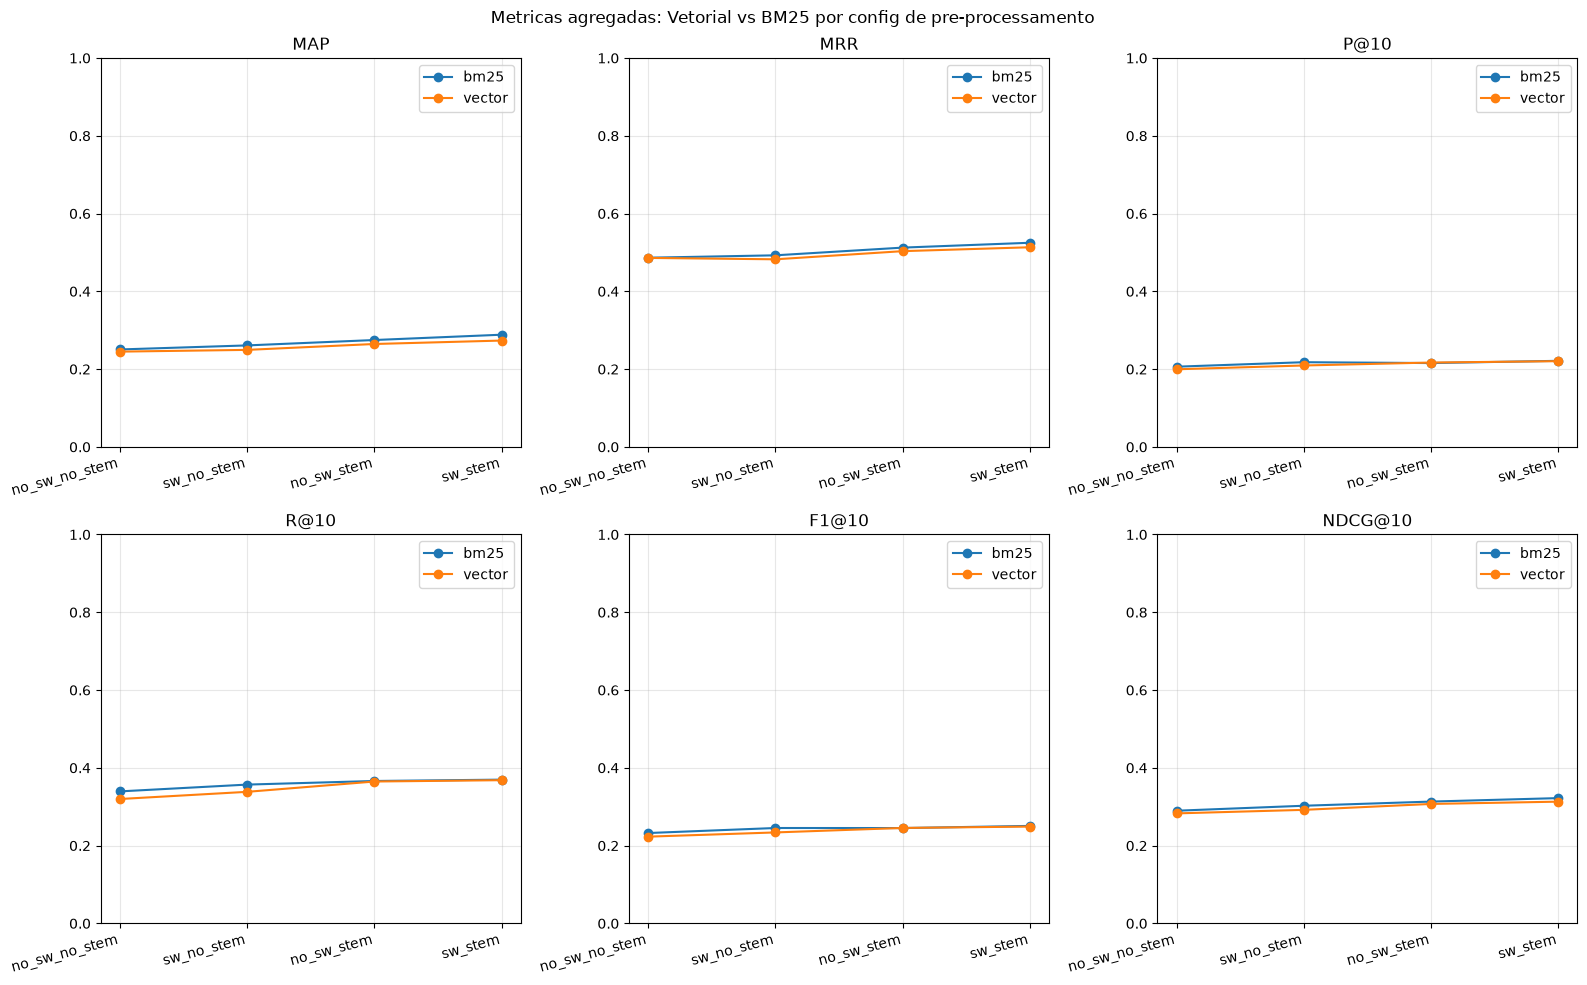

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metricas):
    ax = axes[i]
    for model, group in summary.groupby("model"):
        ax.plot(config_names, 
                [group[group["config"] == c][metrica].values[0] for c in config_names],
                marker="o", label=model)
    ax.set_title(metrica)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Metricas agregadas: Vetorial vs BM25 por config de pre-processamento")
plt.tight_layout()
plt.savefig("results/aggregated/metrics_by_config.png", dpi=150)
plt.show()

In [17]:
# monta df_all/vec/bm25 a partir dos CSVs por-query ja salvos
vec  = pd.read_csv("results/per_query/vector_sw_stem.csv")
bm25 = pd.read_csv("results/per_query/bm25_sw_stem.csv")

vec_labeled  = vec.assign(model="Vetorial")
bm25_labeled = bm25.assign(model="BM25")
df_all = pd.concat([vec_labeled, bm25_labeled], ignore_index=True)


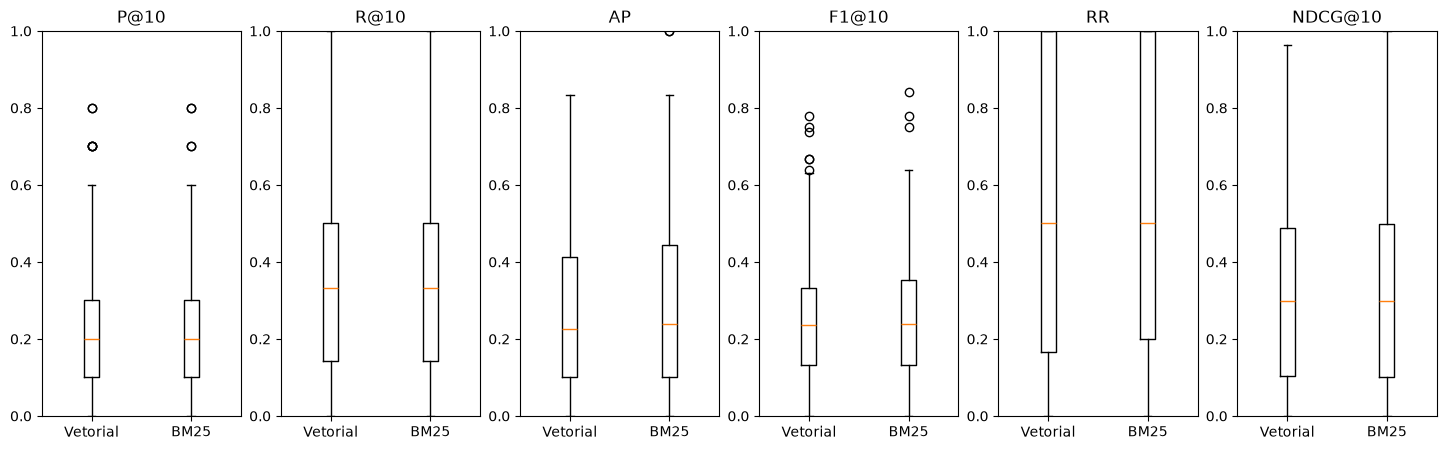

In [18]:
# metricas corretas para os CSVs per_query
metricas_per_query = ["P@10", "R@10", "AP", "F1@10", "RR", "NDCG@10"]

fig, axes = plt.subplots(1, len(metricas_per_query), figsize=(18, 5))
for ax, metrica in zip(axes, metricas_per_query):
    data = [
        df_all[df_all["model"] == "Vetorial"][metrica],
        df_all[df_all["model"] == "BM25"][metrica]
    ]
    ax.boxplot(data, label=["Vetorial", "BM25"])
    ax.set_title(metrica)
    ax.set_xticklabels(["Vetorial", "BM25"])
    ax.set_ylim(0, 1)

In [19]:
merged = vec[["query_id", "AP"]].merge(
    bm25[["query_id", "AP"]], on="query_id", suffixes=("_vec", "_bm25")
)
merged["diff"] = merged["AP_bm25"] - merged["AP_vec"]
merged = merged.sort_values("diff")
merged.to_csv("results/aggregated/per_query_diff.csv", index=False)

print("=== Top-5 Vetorial superior ===")
print(merged.head(5).to_string(index=False))

print("\n=== Top-5 BM25 superior ===")
print(merged.tail(5).to_string(index=False))

=== Top-5 Vetorial superior ===
 query_id   AP_vec  AP_bm25      diff
      145 0.589940 0.161608 -0.428332
       77 0.544775 0.185582 -0.359193
      178 0.475490 0.182697 -0.292793
      191 0.632305 0.361208 -0.271097
      144 0.668849 0.413533 -0.255316

=== Top-5 BM25 superior ===
 query_id   AP_vec  AP_bm25     diff
       36 0.168850 0.502849 0.333999
      205 0.350000 0.700000 0.350000
      173 0.583333 1.000000 0.416667
       81 0.267857 0.833333 0.565476
      167 0.107955 0.750000 0.642045


In [20]:
import pickle
import pandas as pd
from evaluation import binarize_qrels

with open("results/rankings/vector_sw_stem.pkl", "rb") as f:
    vector_rankings = pickle.load(f)
with open("results/rankings/bm25_sw_stem.pkl", "rb") as f:
    bm25_rankings = pickle.load(f)

relevant_bin = binarize_qrels(qrels)

case_queries = {
    "BM25 >> Vetorial":        ["167", "81"],
    "Vetorial >> BM25":        ["145", "77"],
    "Ambos insatisfatorios":   ["31", "22"],
}

rows = []
for case, qids in case_queries.items():
    for qid in qids:
        relevant = relevant_bin.get(qid, set())
        for model_name, rankings in [("Vetorial", vector_rankings), ("BM25", bm25_rankings)]:
            top5 = rankings[qid][:5]
            for rank, (doc_id, score) in enumerate(top5, 1):
                rows.append({
                    "caso":         case,
                    "query_id":     qid,
                    "query_text":   queries[qid].strip().replace("\n", " "),
                    "n_relevantes": len(relevant),
                    "modelo":       model_name,
                    "rank":         rank,
                    "doc_id":       doc_id,
                    "score":        score,
                    "relevante":    doc_id in relevant,
                    "doc_snippet":  docs[doc_id][:150].strip().replace("\n", " "),
                })

query_case_studies = pd.DataFrame(rows)
query_case_studies.to_csv("results/aggregated/query_case_studies.csv", index=False)

pd.set_option("display.max_colwidth", 60)
query_case_studies

,caso,query_id,query_text,n_relevantes,modelo,rank,doc_id,score,relevante,doc_snippet
0,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,1,553,0.368314,False,ablation of glassy materials around blunt bodies of revo...
1,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,2,1099,0.293576,False,a theoretical study of stagnation point ablation . a sim...
2,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,3,1279,0.292589,False,sublimation in a hypersonic environment . a priori kno...
3,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,4,1097,0.273580,False,experimental ablation cooling . this paper presents th...
4,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,5,1100,0.258729,False,an analytical investigation of ablation . an analytical ...
5,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,1,274,23.808362,True,analysis of quartz and teflon shields for a particular r...
6,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,2,553,23.307737,False,ablation of glassy materials around blunt bodies of revo...
7,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,3,1279,22.930036,False,sublimation in a hypersonic environment . a priori kno...
8,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,4,82,20.902792,True,theoretical investigation of the ablation of a glass-typ...
9,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,5,1100,15.275672,False,an analytical investigation of ablation . an analytical ...


In [21]:


with open("results/corpora/sw_stem_docs.pkl", "rb") as f:
    sw_stem_docs = pickle.load(f)

print("=== Tamanho dos documentos citados (BM25 >> Vetorial e Vetorial >> BM25) ===")
doc_pairs = {
    "167 (BM25>>Vet)": [("274", "relevante, rank1 BM25"), ("553", "NAO relevante, rank1 Vetorial")],
    "81  (BM25>>Vet)": [("799", "relevante, rank1 BM25"), ("714", "NAO relevante, rank1 Vetorial")],
    "145 (Vet>>BM25)": [("1045", "relevante, rank1 Vetorial"), ("1126", "NAO relevante, rank1 BM25")],
    "77  (Vet>>BM25)": [("667", "relevante, rank1 Vetorial"), ("1264", "NAO relevante, rank1 BM25")],
}
for qid, pairs in doc_pairs.items():
    for doc_id, label in pairs:
        print(f"  query {qid} | doc {doc_id:>5} | {len(sw_stem_docs[doc_id]):3d} tokens | {label}")

print("\n=== Consultas 'ambos insatisfatorios': onde o doc relevante realmente aparece ===")
for qid in ["31", "22"]:
    doc_id = next(iter(relevant_bin[qid]))
    v_pos = [d for d, _ in vector_rankings[qid]].index(doc_id) + 1
    b_pos = [d for d, _ in bm25_rankings[qid]].index(doc_id) + 1
    print(f"\nquery {qid}: \"{queries[qid].strip()}\"")
    print(f"  doc relevante = {doc_id} | rank no Vetorial: {v_pos}/1400 | rank no BM25: {b_pos}/1400")
    print(f"  texto do doc : {docs[doc_id][:200].strip()}")

=== Tamanho dos documentos citados (BM25 >> Vetorial e Vetorial >> BM25) ===
  query 167 (BM25>>Vet) | doc   274 | 160 tokens | relevante, rank1 BM25
  query 167 (BM25>>Vet) | doc   553 | 104 tokens | NAO relevante, rank1 Vetorial
  query 81  (BM25>>Vet) | doc   799 | 151 tokens | relevante, rank1 BM25
  query 81  (BM25>>Vet) | doc   714 |  67 tokens | NAO relevante, rank1 Vetorial
  query 145 (Vet>>BM25) | doc  1045 |  18 tokens | relevante, rank1 Vetorial
  query 145 (Vet>>BM25) | doc  1126 |  62 tokens | NAO relevante, rank1 BM25
  query 77  (Vet>>BM25) | doc   667 | 153 tokens | relevante, rank1 Vetorial
  query 77  (Vet>>BM25) | doc  1264 | 141 tokens | NAO relevante, rank1 BM25

=== Consultas 'ambos insatisfatorios': onde o doc relevante realmente aparece ===

query 31: "what size of end plate can be safely used to simulate two-dimensional
flow conditions over a bluff cylindrical body of finite aspect ratio ."
  doc relevante = 776 | rank no Vetorial: 1350/1400 | rank no BM25: 13

# Variação de parâmetros do BM25 

In [22]:
import itertools

k1_values = [0.5, 1.2, 2.0]
b_values  = [0, 0.75, 1]

bm25_sw_stem = bm25_models["sw_stem"]

grid_rows = []
for k1, b in itertools.product(k1_values, b_values):
    bm25_sw_stem.k1 = k1
    bm25_sw_stem.b  = b
    rankings = {qid: bm25_sw_stem.rank(qid) for qid in bm25_sw_stem.query_ids}
    df  = evaluate(rankings, qrels)
    agg = aggregate(df)
    grid_rows.append({"k1": k1, "b": b, "MAP": agg["MAP"], "NDCG@10": agg["NDCG@10"]})

# restaura os parametros padrao usados no resto do notebook
bm25_sw_stem.k1, bm25_sw_stem.b = 1.2, 0.75

bm25_param_grid = pd.DataFrame(grid_rows)
os.makedirs("results/aggregated", exist_ok=True)
bm25_param_grid.to_csv("results/aggregated/bm25_param_grid.csv", index=False)
print(bm25_param_grid.to_string(index=False))

 k1    b      MAP  NDCG@10
0.5 0.00 0.258785 0.289492
0.5 0.75 0.277033 0.311227
0.5 1.00 0.276188 0.310645
1.2 0.00 0.266390 0.299719
1.2 0.75 0.288489 0.322159
1.2 1.00 0.289460 0.323967
2.0 0.00 0.268176 0.300670
2.0 0.75 0.292517 0.328069
2.0 1.00 0.290898 0.327592


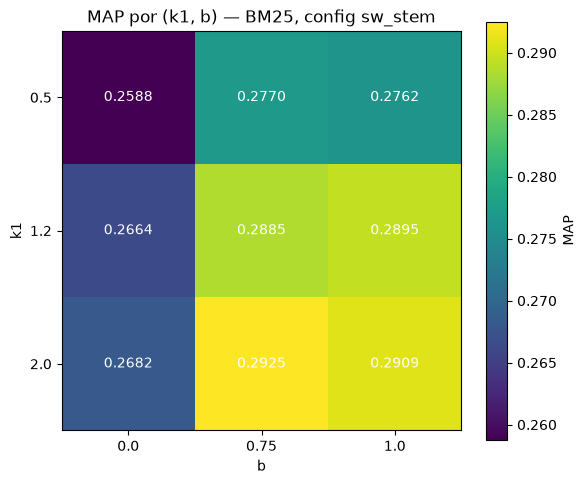

In [23]:
pivot_map = bm25_param_grid.pivot(index="k1", columns="b", values="MAP")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot_map.values, cmap="viridis")
ax.set_xticks(range(len(pivot_map.columns))); ax.set_xticklabels(pivot_map.columns)
ax.set_yticks(range(len(pivot_map.index)));   ax.set_yticklabels(pivot_map.index)
ax.set_xlabel("b")
ax.set_ylabel("k1")
ax.set_title("MAP por (k1, b) — BM25, config sw_stem")
for i in range(len(pivot_map.index)):
    for j in range(len(pivot_map.columns)):
        ax.text(j, i, f"{pivot_map.values[i, j]:.4f}", ha="center", va="center", color="white")
plt.colorbar(im, ax=ax, label="MAP")
plt.tight_layout()
plt.savefig("results/aggregated/bm25_param_heatmap.png", dpi=150)
plt.show()

## Consulta onde `b` muda perceptivelmente o Top-10 (k1 fixo em 1.2)

In [24]:
bm25_sw_stem.k1 = 1.2

bm25_sw_stem.b = 0.0
top10_b0 = {qid: [d for d, _ in bm25_sw_stem.rank(qid)[:10]] for qid in bm25_sw_stem.query_ids}

bm25_sw_stem.b = 1.0
top10_b1 = {qid: [d for d, _ in bm25_sw_stem.rank(qid)[:10]] for qid in bm25_sw_stem.query_ids}

# restaura o parametro padrao
bm25_sw_stem.b = 0.75

diffs = {qid: len(set(top10_b0[qid]) ^ set(top10_b1[qid])) for qid in bm25_sw_stem.query_ids}
best_qid = max(diffs, key=diffs.get)
print(f"Consulta escolhida: {best_qid} (diferenca simetrica de {diffs[best_qid]} documentos no Top-10)")
print(f"Texto: {queries[best_qid].strip()}")

relevant = relevant_bin.get(best_qid, set())

comparison_rows = []
for rank, doc_id in enumerate(top10_b0[best_qid], 1):
    comparison_rows.append({"rank": rank, "b=0 doc_id": doc_id, "relevante (b=0)": doc_id in relevant})
for rank, doc_id in enumerate(top10_b1[best_qid], 1):
    comparison_rows[rank - 1]["b=1 doc_id"] = doc_id
    comparison_rows[rank - 1]["relevante (b=1)"] = doc_id in relevant

b_comparison = pd.DataFrame(comparison_rows)
b_comparison.to_csv("results/aggregated/bm25_b_param_query_comparison.csv", index=False)
b_comparison

Consulta escolhida: 124 (diferenca simetrica de 16 documentos no Top-10)
Texto: in what areas, other than low density wind tunnel flows, is viscous
compressible flow in slender channels a problem .
what analytical investigations have been made of the stability of
conical shells . how do the results compare with experiment .


,rank,b=0 doc_id,relevante (b=0),b=1 doc_id,relevante (b=1)
0,1,941,False,941,False
1,2,792,False,898,False
2,3,25,False,516,False
3,4,625,False,514,False
4,5,1313,False,938,False
5,6,442,False,1288,False
6,7,9,False,442,False
7,8,1274,False,1070,False
8,9,656,False,934,False
9,10,1319,False,183,False


# Modificação de consultas 

5 consultas originais do Cranfield, cada uma com uma versão modificada manualmente

| # | query_id | Estratégia | Original → Modificada |
|---|---|---|---|
| 1 | 31  | Generalização (remove qualificador) | "...bluff **cylindrical** body..." → "...bluff body..." |
| 2 | 167 | Remoção de termos (compressão) | "exact solution methods for calculating the ablative mass loss..." → "the ablative mass loss..." |
| 3 | 145 | Sinônimo ("cylinders"→"shells") | "...pressurized **cylinders** in bending." → "...pressurized **shells** in bending." |
| 4 | 100 | Mais específica (acréscimo de qualificadores) | "...effects of **initial imperfections**... **cylindrical shells**..." → "...effects of **small initial geometric imperfections**... **thin** cylindrical shells..." |
| 5 | 50  | Remoção de termos + generalização | "...effects of **small amounts of** gas rarefaction...**slender** bodies of revolution." → "...effects of gas rarefaction...bodies of revolution." |

In [25]:
query_pairs = [
    {
        "query_id":   "31",
        "estrategia": "Generalizacao (remove qualificador)",
        "modificada": "what size of end plate can be safely used to simulate two-dimensional flow conditions over a bluff body of finite aspect ratio .",
    },
    {
        "query_id":   "167",
        "estrategia": "Remocao de termos (compressao)",
        "modificada": "the ablative mass loss of a material ablating at high temperatures .",
    },
    {
        "query_id":   "145",
        "estrategia": "Sinonimo (cylinders -> shells)",
        "modificada": "what are the best experimental data and classical small deflection theory analyses available for pressurized shells in bending .",
    },
    {
        "query_id":   "100",
        "estrategia": "Mais especifica (acrescimo de qualificadores)",
        "modificada": "what are the effects of small initial geometric imperfections on the elastic buckling of thin cylindrical shells under axial compression .",
    },
    {
        "query_id":   "50",
        "estrategia": "Remocao de termos + generalizacao",
        "modificada": "what are the effects of gas rarefaction on the characteristics of the boundary layers on bodies of revolution .",
    },
]

vector_sw_stem = vector_models["sw_stem"]

reformulation_rows = []
for pair in query_pairs:
    qid = pair["query_id"]
    original_text = queries[qid].strip().replace("\n", " ")
    modified_text = pair["modificada"]
    relevant      = relevant_bin.get(qid, set())

    for versao, text in [("original", original_text), ("modificada", modified_text)]:
        vec_top10  = vector_sw_stem.search(text, remove_stopwords=True, stem=True)[:10]
        bm25_top10 = bm25_sw_stem.search(text, remove_stopwords=True, stem=True)[:10]

        for modelo, top10 in [("Vetorial", vec_top10), ("BM25", bm25_top10)]:
            for rank, (doc_id, score) in enumerate(top10, 1):
                reformulation_rows.append({
                    "query_id":    qid,
                    "estrategia":  pair["estrategia"],
                    "versao":      versao,
                    "query_text":  text,
                    "modelo":      modelo,
                    "rank":        rank,
                    "doc_id":      doc_id,
                    "score":       score,
                    "relevante_para_query_original": doc_id in relevant,
                })

query_reformulation = pd.DataFrame(reformulation_rows)
query_reformulation.to_csv("results/aggregated/query_reformulation.csv", index=False)
query_reformulation

,query_id,estrategia,versao,query_text,modelo,rank,doc_id,score,relevante_para_query_original
0,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,1,751,0.374748,False
1,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,2,68,0.188009,False
2,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,3,918,0.171308,False
3,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,4,247,0.165531,False
4,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,5,916,0.155540,False
...,...,...,...,...,...,...,...,...,...
195,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,6,1263,11.730153,False
196,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,7,192,11.317325,False
197,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,8,353,11.294747,False
198,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,9,421,11.156272,False


In [26]:
# resumo: quantos documentos do Top-10 permanecem iguais entre original e modificada
summary_rows = []
for pair in query_pairs:
    qid = pair["query_id"]
    for modelo in ["Vetorial", "BM25"]:
        orig_docs = query_reformulation.query("query_id == @qid and versao == 'original' and modelo == @modelo")["doc_id"].tolist()
        mod_docs  = query_reformulation.query("query_id == @qid and versao == 'modificada' and modelo == @modelo")["doc_id"].tolist()
        overlap = len(set(orig_docs) & set(mod_docs))
        summary_rows.append({
            "query_id":              qid,
            "estrategia":            pair["estrategia"],
            "modelo":                modelo,
            "docs_em_comum_top10":   overlap,
            "docs_diferentes_top10": 10 - overlap,
        })

reformulation_summary = pd.DataFrame(summary_rows)
reformulation_summary.to_csv("results/aggregated/query_reformulation_summary.csv", index=False)
print(reformulation_summary.to_string(index=False))

query_id                                    estrategia   modelo  docs_em_comum_top10  docs_diferentes_top10
      31           Generalizacao (remove qualificador) Vetorial                    9                      1
      31           Generalizacao (remove qualificador)     BM25                    8                      2
     167                Remocao de termos (compressao) Vetorial                    8                      2
     167                Remocao de termos (compressao)     BM25                    7                      3
     145                Sinonimo (cylinders -> shells) Vetorial                    3                      7
     145                Sinonimo (cylinders -> shells)     BM25                    5                      5
     100 Mais especifica (acrescimo de qualificadores) Vetorial                    9                      1
     100 Mais especifica (acrescimo de qualificadores)     BM25                    8                      2
      50             Remocao

In [27]:
# quantos dos documentos relevantes continuam no Top-10 apos a modificacao
relevantes_no_top10 = (
    query_reformulation
    .groupby(["query_id", "versao", "modelo"])["relevante_para_query_original"]
    .sum()
    .unstack("versao")[["original", "modificada"]]
)
relevantes_no_top10

versao             original  modificada
query_id modelo                        
100      BM25             3           2
         Vetorial         2           2
145      BM25             2           0
         Vetorial         4           3
167      BM25             2           2
         Vetorial         1           1
31       BM25             0           0
         Vetorial         0           0
50       BM25             1           1
         Vetorial         1           1

# analise de erros

In [28]:
# falsos positivos: doc explicitamente julgado -1 que aparece no rank 1 em ambos os modelos
neg_judged = [(q, d) for q, d, r in qrels if r == -1]

fp_candidates = []
for qid, doc_id in neg_judged:
    v_top1 = vector_rankings[qid][0][0]
    b_top1 = bm25_rankings[qid][0][0]
    if doc_id == v_top1 and doc_id == b_top1:
        fp_candidates.append((qid, doc_id))

print(f"Candidatos a falso positivo (rank1 em Vetorial E BM25, julgado -1): {len(fp_candidates)}")
print(fp_candidates[:10])

Candidatos a falso positivo (rank1 em Vetorial E BM25, julgado -1): 71
[('3', '485'), ('6', '491'), ('7', '492'), ('11', '495'), ('13', '496'), ('16', '498'), ('20', '500'), ('21', '502'), ('23', '892'), ('31', '751')]


In [29]:
error_rows = []

fp_cases = [("3", "485"), ("6", "491")]
for qid, doc_id in fp_cases:
    error_rows.append({
        "caso":       "falso_positivo",
        "query_id":   qid,
        "query_text": queries[qid].strip().replace("\n", " "),
        "doc_id":     doc_id,
        "doc_text":   docs[doc_id][:400].strip().replace("\n", " "),
        "rank_vetorial": [d for d, _ in vector_rankings[qid]].index(doc_id) + 1,
        "rank_bm25":     [d for d, _ in bm25_rankings[qid]].index(doc_id) + 1,
        "relevance_qrel": -1,
    })

fn_qid, fn_doc = "124", "967"
error_rows.append({
    "caso":       "falso_negativo",
    "query_id":   fn_qid,
    "query_text": queries[fn_qid].strip().replace("\n", " "),
    "doc_id":     fn_doc,
    "doc_text":   docs[fn_doc][:400].strip().replace("\n", " "),
    "rank_vetorial": [d for d, _ in vector_rankings[fn_qid]].index(fn_doc) + 1,
    "rank_bm25":     [d for d, _ in bm25_rankings[fn_qid]].index(fn_doc) + 1,
    "relevance_qrel": [r for q, d, r in qrels if q == fn_qid and d == fn_doc][0],
})

error_analysis = pd.DataFrame(error_rows)
error_analysis.to_csv("results/aggregated/error_analysis.csv", index=False)
pd.set_option("display.max_colwidth", 80)
error_analysis

,caso,query_id,query_text,doc_id,doc_text,rank_vetorial,rank_bm25,relevance_qrel
0,falso_positivo,3,what problems of heat conduction in composite slabs have been solved so far .,485,linear heat flow in a composite slab . the temperature is determined as a ...,1,1,-1
1,falso_positivo,6,what theoretical and experimental guides do we have as to turbulent couette ...,491,on the close relationship between turbulent plane-couette and pressure flows...,1,1,-1
2,falso_negativo,124,"in what areas, other than low density wind tunnel flows, is viscous compress...",967,a study of laminar compressible viscous pipe flow accelerated by an axial bo...,133,131,2
